# Interactive Molecular Screening Pipeline - Test & Demonstration

This notebook provides an interactive dashboard to customize a cationic scaffold, apply structural constraints, and run the full generative and predictive screening pipeline.

### Pipeline Workflow

1. **Combinatorial Generation & UI Interaction** (`.generation()`)
   * **Interactive Setup:** Launches the widget-based environment to choose a base cation, configure anchor sites, and define substituent groups.
   * **Library Expansion:** Generates functionalized cations based on combinatorial substitution rules, validated against internal structural constraints.

2. **Synthetic Accessibility Filtering** (`.sascore()` & `.pair_with_anions()`)
   Computes **SAScores** and discards structures exceeding a complexity threshold. Surviving cations are then paired with the anion library to construct the complete salt matrix.

3. **Deep Learning $T_m$ Prediction** (`.tm()`)
   Extracts molecular descriptors and runs the ensemble **Parallel-Scaffold CNN (PSCNN)** inference to predict melting points.

4. **Visualization & Analysis** (`.plot()`)
   Transforms results into publication-quality figures: `hist` for distribution analysis (e.g., `sascore`, `tm`), `similarity` for structural clustering, and `matrix` for comparative property grid screening.

5. **Data Serialization** (`.save()` & `.load()`)
   * **Persistence (`.save()`):** Serializes the internal DataFrame (`self.df`) into `.csv` or `.xlsx` formats, allowing for precise output control via selective column filtering.
   * **Rehydration (`.load()`):** Restores a previously saved library, enabling seamless workflow resumption and maintaining consistency across independent sessions.

---
*The pipeline relies on method chaining, allowing for a modular, reproducible, and efficient screening workflow from initial scaffold design to final property reporting.*

In [1]:
import sys
import os

%load_ext autoreload
%autoreload 2
    
sys.path.append(os.path.abspath('../'))

from ils_screening_tm.main import ILsScreening

ils = ILsScreening()

2026-07-03 16:19:48.092208: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-03 16:19:48.128893: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-03 16:19:48.996928: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


###  Combinatorial Generation & UI Framework (`.generation()`)

This method serves as the orchestrator for the structural setup and library functionalization of your cations. 

* **If executed without a predefined scaffold:** It dynamically spins up an interactive `ipywidgets` dashboard directly inside the cell. This user interface allows you to select a base chemical family (Imidazolium, Pyridinium, etc.), cut specific atom indices to create new substitution sites, and define dynamic structural symmetries/anchor groups.
* **Core Computational Logic:** Once the scaffold choices are validated, the generation engine executes a combinatorial substitution workflow. It pairs the vacant anchor positions with your defined substituent libraries, filtering out chemically invalid structures using internal SMARTS structural constraints.

*The results are registered in memory inside the pipeline's internal state (`self.df`), bypassing intermediate disk write overheads.*

In [2]:
ils.generation()

💡 No scaffold layout defined. Launching interactive Widget interface...


Label(value='🔧 Screening Bounds Settings:')

Dropdown(description='Cation Core:', options=(('Pyrrolidinium', 0), ('Pyridinium', 1), ('Piperidinium', 2), ('…

Output()

ILsScreening Pipeline (Status: Empty Sandbox)

###  High-Resolution Molecular Structure Rendering (`.show()`)

Once the filtering and deep learning predictions are complete, this method provides a direct visual validation of the structural output.

* **Randomized Sub-Sampling:** To avoid crashing the notebook interface or overwhelming the user with thousands of rows, `sample_size` extracts a clean, randomized subset of the final screened dataset.
* **Dual-Ion Visual Grid:** It utilizes RDKit's rendering engine to draw clean 2D chemical structures, automatically pairing each surviving cation right alongside its corresponding counter-anion. 
* **Properties Overlay:** Each molecular tile in the grid is annotated with its final computed screening attributes (such as predicted $T_m$ and SAScore) for rapid visual auditing.

🎨 Displaying 5 random generated Cations structures:


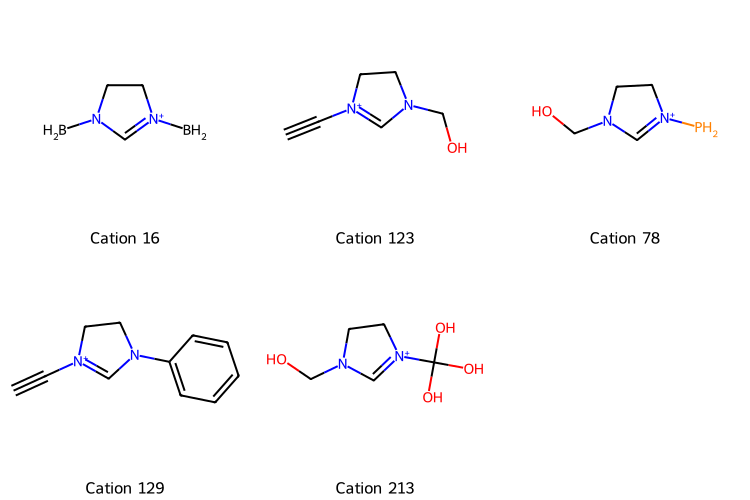

ILsScreening Pipeline (Status: Generated Cations Registry (121 structures))

In [3]:
ils.show(sample_size=5)

### Data Serialization & Export Framework (`.save()`)

This method ensures the persistence of the library's state for external analysis or long-term archiving.

* **Format Agnostic:** Serializes the entire DataFrame into standardized formats (`.csv`, `.xlsx`), ensuring immediate compatibility with third-party analytical tools.

In [ ]:
ils.save("Cations.csv")

### Synthetic Accessibility Filtering & Anion Pairing (`.sascore()`)

This method acts as a strict structural gatekeeper to ensure that only realistic, synthetically viable molecules proceed to the deep learning stage.

* **SAScore Computation:** It evaluates every unique generated cation using RDKit's Synthetic Accessibility (SA) scoring algorithm. The score ranges from 1 (very easy to synthesize) to 10 (extremely difficult/unstable).
* **The Synthesis Gate:** By enforcing `threshold=6.0`, the pipeline instantly discards overly complex, highly strained, or chemically unstable cationic structures.
* **Automated Salt Crossover:** Surviving cations that successfully clear the gate are automatically cross-joined (Cartesian product) with the package's internal standard anion library, instantly expanding the dataset from individual ions into a complete matrix of paired ionic liquid salts.

In [4]:
ils.sascore(threshold=6.0)

🧪 [SAScore] Calculating chemical accessibility vectors...
✂️ [SAScore Filter] 110 / 121 cations retained under threshold (<= 6.0).


ILsScreening Pipeline (Status: Generated Cations Registry (110 structures))

In [ ]:
ils.save("Cations_SAScore.csv")

### Visualization & Analysis Framework (`.plot()`)

This method serves as the central engine for data interpretation, transforming internal computational results into publication-quality visualizations.

* **Multi-Modal Analytics:** Supports diverse representation types including `hist` for property distributions (e.g., `sascore`, `tm`), `similarity` for structural clustering, and `matrix` for comparative property grid screening.
* **Automated Rendering:** Dynamically handles data scaling, statistical labeling, and layout finalization to ensure clarity and professional-grade aesthetics for research manuscripts.

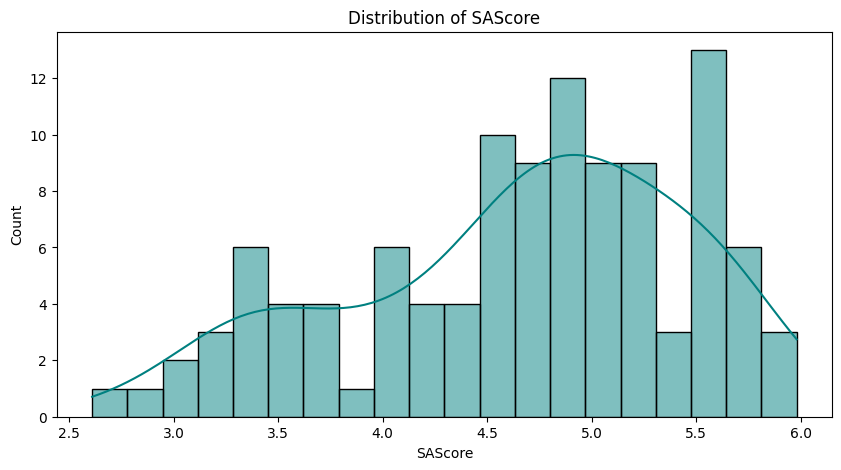

In [5]:
ils.plot(prop='sascore', kind='hist')

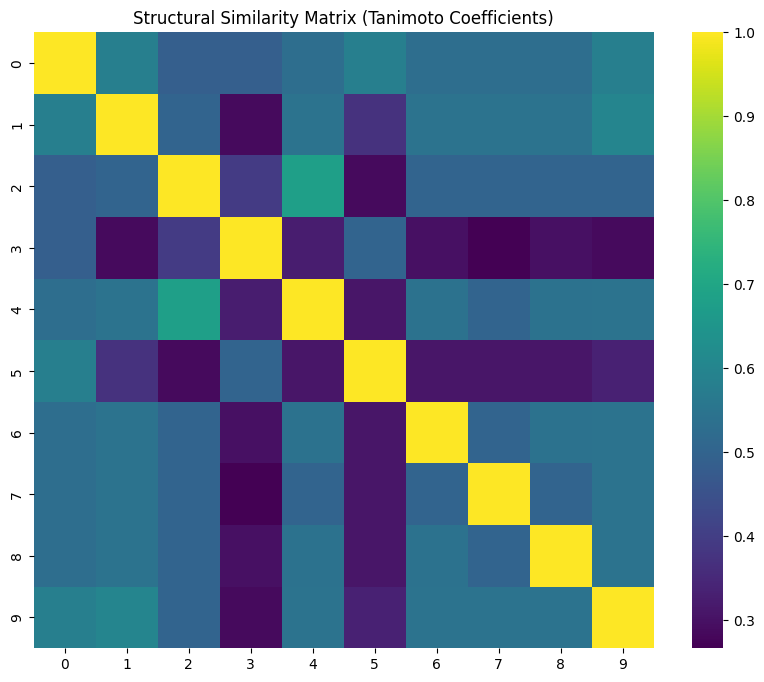

In [6]:
ils.plot(kind='similarity', max_display=10)

### Automated Salt Matrix Crossover (`.pair_with_anions()`)

This method handles the transitional bridge from individual ionic components to complete, realistic salt pairs.

* **Cartesian Product Cross-Join:** It automatically extracts all unique cations that have successfully cleared your previous structural filters and performs a full combinatorial cross-join with the package's internal anion library.
* **Salt Matrix Assembly:** Each row in the internal dataset is transformed from a single cation into a distinct, paired Ionic Liquid (IL) structural matrix entry containing both the explicit cation and anion building blocks.
* **Property Conservation:** It maps and carries over all previously computed descriptors and properties (such as the cation's SAScore) into the newly generated paired salt dataset, preparing it directly for the downstream deep learning prediction layers.

In [7]:
ils.pair_with_anions()

🔗 [Anion Pairing] Matrix built: Generated 54230 full salt configurations.


ILsScreening Pipeline (Status: Paired Library (54230 salt configurations))

🎨 Displaying 5 random Screened Salt Pairs (Left: Cation | Right: Anion):


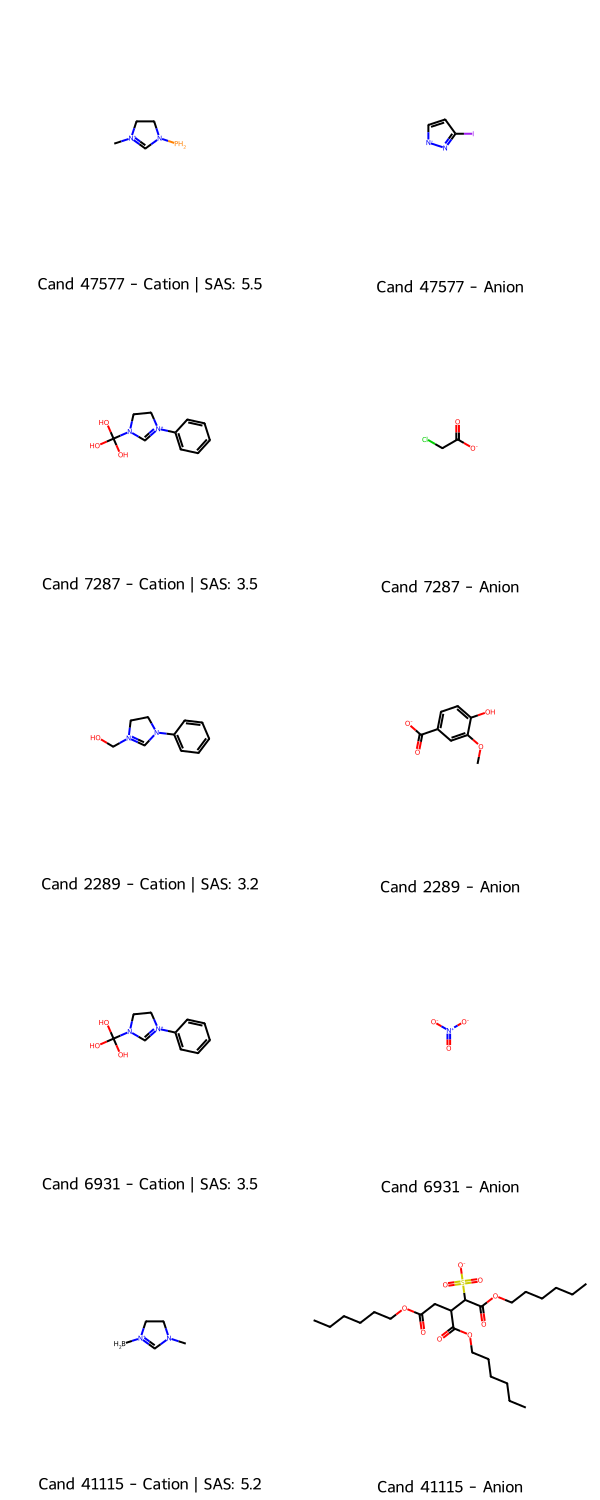

ILsScreening Pipeline (Status: Paired Library (54230 salt configurations))

In [8]:
ils.show(sample_size=5)

In [ ]:
ils.save("IL_SAScore.csv")

### Deep Learning Melting Point Prediction (`.tm()`)

This method runs the core predictive engine of the pipeline, using deep learning to forecast the melting point ($T_m$) of the generated ionic liquid matrix.

* **High-Dimensional Feature Extraction:** The pipeline automatically computes 209 mathematical Mordred structural descriptors for both the cation and the anion blocks, standardizing them via pre-trained feature scalers.
* **Parallel-Scaffold CNN Ensemble:** The processed descriptor blocks are fed into a 5-Fold Cross-Validation Ensemble of **Parallel-Scaffold Convolutional Neural Networks (PSCNN)**. This dual-input architecture processes the cation and anion features independently before combining them to predict the final melting point.
* **Thermal Screening:** By applying `threshold_c=100.0`, the pipeline enforces a strict room-temperature/low-melting cutoff. Any paired salt with an ensemble-averaged predicted melting point greater than $100^\circ\text{C}$ is discarded, isolating the top low-melting candidates.

In [ ]:
ils.tm(threshold_c=100.0)

### Data Persistence & Retrieval Framework (`.load()`)

This method restores a previously serialized library, enabling the resumption of screening workflows or downstream analysis from a saved state.

* **Seamless Rehydration:** Restores the full DataFrame from standardized formats (`.csv`, `.xlsx`), ensuring that all structural descriptors and previously calculated properties are immediately available for further processing.

In [9]:
ils.load("ILs_SAScore_Tm.csv")

✅ Data loaded successfully from 'ILs_SAScore_Tm.csv' (48949 rows).


ILsScreening Pipeline (Status: Screened Library (48949 salts with predicted Tm))

🎨 Displaying 5 random Screened Salt Pairs (Left: Cation | Right: Anion):


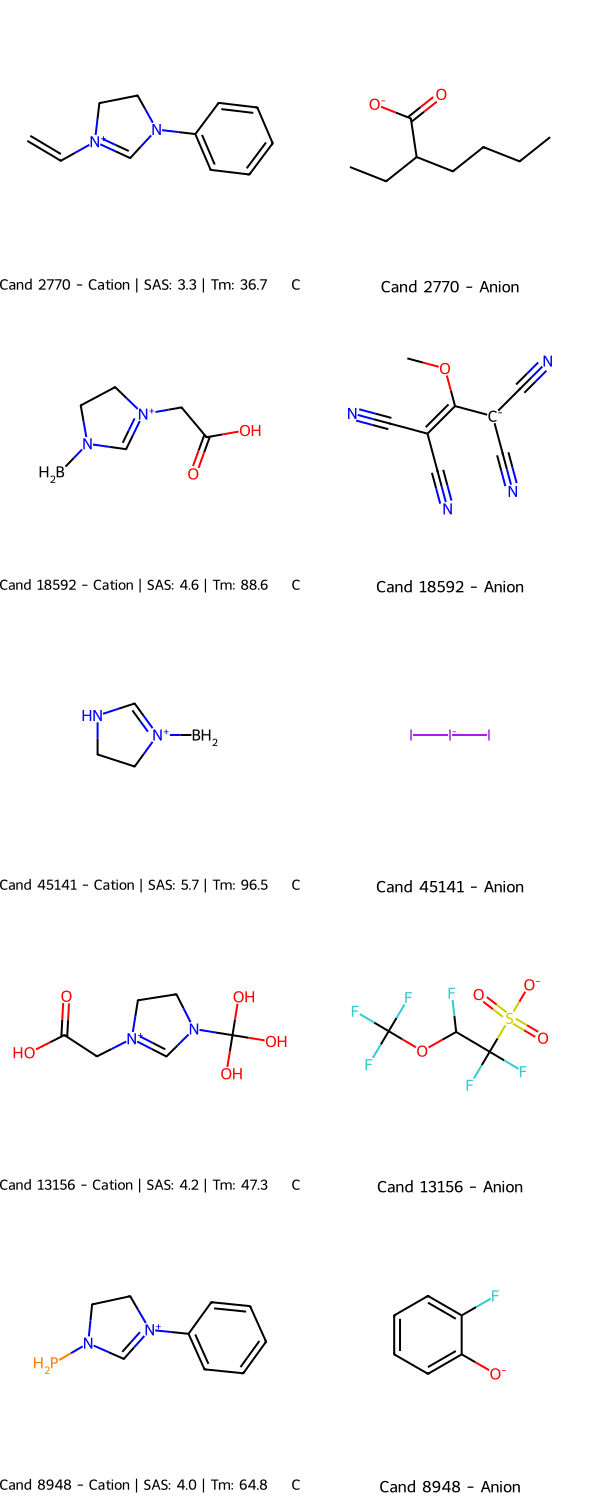

ILsScreening Pipeline (Status: Screened Library (48949 salts with predicted Tm))

In [10]:
ils.show(sample_size=5)

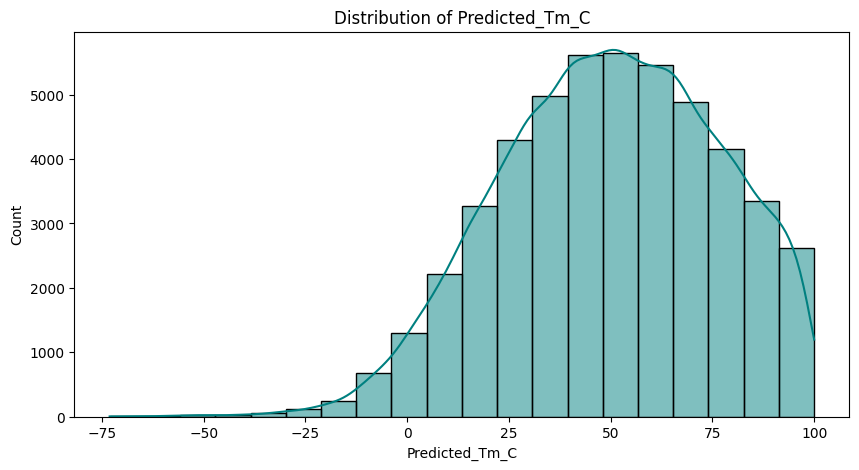

In [11]:
ils.plot(prop='tm', kind='hist')

💾 [Plot] Figure saved to matrix_tm.png


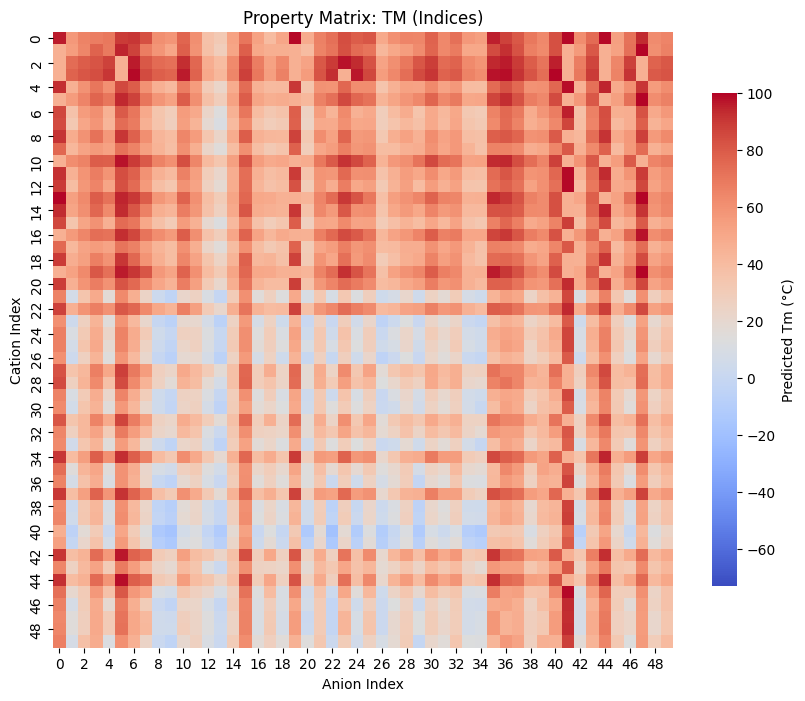

In [12]:
ils.plot(prop='tm', kind='matrix',max_display=50, save_path='matrix_tm.png')